# Regresión Logística Multiclase — Goodreads Best Books Ever

## Descripción del Problema

Este cuadernillo implementa un modelo de **regresión logística multiclase** aplicado al dataset *Goodreads Best Books Ever*. El objetivo es predecir el **nivel de valoración** de un libro (Bajo, Medio, Alto, Muy Alto) a partir de sus características numéricas y categóricas.

El dataset fue obtenido de Kaggle:  
https://www.kaggle.com/datasets/meetnaren/goodreads-best-books?select=book_data.csv

### Condiciones del trabajo:
- Preprocesamiento con **Pandas**.
- División **80% entrenamiento / 20% prueba** (sin fuga de datos entre conjuntos).
- Normalización ajustada **solo con datos de entrenamiento**.
- Dataset **balanceado** por clase.
- Implementación desde cero.
- Visualización de curvas de **costo y precisión**.

## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

# Semilla para reproducibilidad
np.random.seed(42)

## 2. Carga y Exploración del Dataset

El archivo `book_data.csv` contiene información de los mejores libros según Goodreads. Se carga con Pandas y se realiza una exploración inicial para entender su estructura.

In [2]:
# Ajusta la ruta según tu entorno (Colab, local, etc.)
df = pd.read_csv('book_data.csv')

print(f"Forma del dataset: {df.shape}")
print(f"\nColumnas ({len(df.columns)}):")
print(df.columns.tolist())
print("\nPrimeras filas:")
df.head()

Forma del dataset: (54301, 12)

Columnas (12):
['book_authors', 'book_desc', 'book_edition', 'book_format', 'book_isbn', 'book_pages', 'book_rating', 'book_rating_count', 'book_review_count', 'book_title', 'genres', 'image_url']

Primeras filas:


,book_authors,book_desc,book_edition,book_format,book_isbn,book_pages,book_rating,book_rating_count,book_review_count,book_title,genres,image_url
0,Suzanne Collins,Winning will make you famous. Losing means cer...,NaN,Hardcover,9.78044E+12,374 pages,4.33,5519135,160706,The Hunger Games,Young Adult|Fiction|Science Fiction|Dystopia|F...,https://images.gr-assets.com/books/1447303603l...
1,J.K. Rowling|Mary GrandPré,There is a door at the end of a silent corrido...,US Edition,Paperback,9.78044E+12,870 pages,4.48,2041594,33264,Harry Potter and the Order of the Phoenix,Fantasy|Young Adult|Fiction,https://images.gr-assets.com/books/1255614970l...
2,Harper Lee,The unforgettable novel of a childhood in a sl...,50th Anniversary,Paperback,9.78006E+12,324 pages,4.27,3745197,79450,To Kill a Mockingbird,Classics|Fiction|Historical|Historical Fiction...,https://images.gr-assets.com/books/1361975680l...
3,Jane Austen|Anna Quindlen|Mrs. Oliphant|George...,«È cosa ormai risaputa che a uno scapolo in po...,"Modern Library Classics, USA / CAN",Paperback,9.78068E+12,279 pages,4.25,2453620,54322,Pride and Prejudice,Classics|Fiction|Romance,https://images.gr-assets.com/books/1320399351l...
4,Stephenie Meyer,About three things I was absolutely positive.F...,NaN,Paperback,9.78032E+12,498 pages,3.58,4281268,97991,Twilight,Young Adult|Fantasy|Romance|Paranormal|Vampire...,https://images.gr-assets.com/books/1361039443l...


In [3]:
print("Tipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Verificar columnas disponibles
print("\n=== Columnas útiles para modelado ===")
useful_cols = ['book_rating', 'book_rating_count', 'book_review_count', 
               'book_pages', 'book_format', 'genres', 'book_authors']
for col in useful_cols:
    if col in df.columns:
        print(f"✓ {col}: presente")
    else:
        print(f"✗ {col}: NO presente")

Tipos de datos:
book_authors          object
book_desc             object
book_edition          object
book_format           object
book_isbn             object
book_pages            object
book_rating          float64
book_rating_count      int64
book_review_count      int64
book_title            object
genres                object
image_url             object
dtype: object

Valores nulos por columna:
book_authors             0
book_desc             1331
book_edition         48848
book_format           1656
book_isbn            12866
book_pages            2522
book_rating              0
book_rating_count        0
book_review_count        0
book_title               0
genres                3242
image_url              683
dtype: int64

=== Columnas útiles para modelado ===
✓ book_rating: presente
✓ book_rating_count: presente
✓ book_review_count: presente
✓ book_pages: presente
✓ book_format: presente
✓ genres: presente
✓ book_authors: presente


## 3. Preprocesamiento con Pandas

Se aplica un pipeline completo de preprocesamiento:
1. Limpieza de valores nulos.
2. Conversión y extracción de columnas numéricas.
3. Ingeniería de características (One-Hot Encoding para categóricas).
4. Creación de la variable objetivo en 4 clases balanceadas.
5. Balanceo del dataset mediante submuestreo.

In [4]:
# --- 3.1 Copia de trabajo 
data = df.copy()

# --- Limpiar book_pages (extraer número) 
if 'book_pages' in data.columns:
    data['pages'] = data['book_pages'].astype(str).str.extract('(\d+)')[0]
    data['pages'] = pd.to_numeric(data['pages'], errors='coerce')

# --- Limpiar book_rating (target) 
if 'book_rating' in data.columns:
    data['rating'] = pd.to_numeric(data['book_rating'], errors='coerce')

# --- Limpiar book_rating_count y book_review_count 
if 'book_rating_count' in data.columns:
    data['rating_count'] = pd.to_numeric(data['book_rating_count'], errors='coerce')
if 'book_review_count' in data.columns:
    data['review_count'] = pd.to_numeric(data['book_review_count'], errors='coerce')

# Eliminar filas sin rating
data = data.dropna(subset=['rating'])
print(f"Filas tras eliminar NaN en rating: {len(data)}")
print(f"Columnas disponibles: {data.columns.tolist()}")

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KEVIN\AppData\Local\Temp\ipykernel_10928\2678391564.py:6: SyntaxWarning: invalid escape sequence '\d'
  data['pages'] = data['book_pages'].astype(str).str.extract('(\d+)')[0]


Filas tras eliminar NaN en rating: 54301
Columnas disponibles: ['book_authors', 'book_desc', 'book_edition', 'book_format', 'book_isbn', 'book_pages', 'book_rating', 'book_rating_count', 'book_review_count', 'book_title', 'genres', 'image_url', 'pages', 'rating', 'rating_count', 'review_count']


Distribución de clases (antes de balancear):
rating_class
0    12486
1     9371
2    10907
3    21537
Name: count, dtype: int64


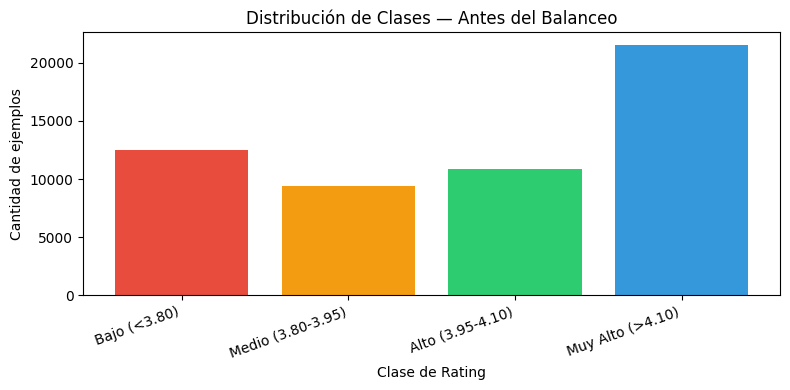

In [5]:
# --- 3.4 Crear la variable objetivo: 4 clases de rating
# Se dividen los ratings en cuartiles para crear 4 clases balanceadas naturalmente
bins = [0, 3.80, 3.95, 4.10, 5.0]
labels = [0, 1, 2, 3]  # Bajo, Medio, Alto, Muy Alto
label_names = {0: 'Bajo (<3.80)', 1: 'Medio (3.80-3.95)', 2: 'Alto (3.95-4.10)', 3: 'Muy Alto (>4.10)'}

data['rating_class'] = pd.cut(data['rating'], bins=bins, labels=labels, include_lowest=True)
data = data.dropna(subset=['rating_class'])
data['rating_class'] = data['rating_class'].astype(int)

print("Distribución de clases (antes de balancear):")
print(data['rating_class'].value_counts().sort_index())

# Visualizar distribución inicial
fig, ax = plt.subplots(figsize=(8, 4))
counts = data['rating_class'].value_counts().sort_index()
ax.bar([label_names[i] for i in counts.index], counts.values, color=['#e74c3c','#f39c12','#2ecc71','#3498db'])
ax.set_title('Distribución de Clases — Antes del Balanceo')
ax.set_xlabel('Clase de Rating')
ax.set_ylabel('Cantidad de ejemplos')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# --- 3.5 Balanceo mediante submuestreo (undersampling) 
# Se toma la misma cantidad de ejemplos para cada clase (la menor)
min_class_count = data['rating_class'].value_counts().min()
print(f"Ejemplos por clase tras balanceo: {min_class_count}")

balanced_parts = []
for cls in [0, 1, 2, 3]:
    subset = data[data['rating_class'] == cls].sample(n=min_class_count, random_state=42)
    balanced_parts.append(subset)

data_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDataset balanceado — Total de ejemplos: {len(data_balanced)}")
print("Distribución por clase:")
print(data_balanced['rating_class'].value_counts().sort_index())

# Verificar que m >= 5000
assert len(data_balanced) >= 5000, f"El dataset tiene {len(data_balanced)} ejemplos, se requieren al menos 5000."
print(f"\n✓ m = {len(data_balanced)} ejemplos (requisito m >= 5000 cumplido)")

Ejemplos por clase tras balanceo: 9371

Dataset balanceado — Total de ejemplos: 37484
Distribución por clase:
rating_class
0    9371
1    9371
2    9371
3    9371
Name: count, dtype: int64

✓ m = 37484 ejemplos (requisito m >= 5000 cumplido)


In [21]:
from IPython.display import display, HTML

# Muestra 3 libros por clase para ilustrar el dataset multimodal
sample = data_balanced.groupby('rating_class').head(3).head(12)

label_colors = {0: '#fde8e8', 1: '#fef3cd', 2: '#d4edda', 3: '#cce5ff'}
label_text   = {0: '#721c24', 1: '#856404', 2: '#155724', 3: '#004085'}

html = '<h4 style="font-family:sans-serif">Portadas por clase de rating</h4>'
html += '<div style="display:grid; grid-template-columns:repeat(6,1fr); gap:10px; font-family:sans-serif">'

for _, row in sample.iterrows():
    url   = row['image_url']
    title = str(row['book_title'])[:22]
    rating = row['book_rating']
    cls   = int(row['rating_class'])
    bg    = label_colors[cls]
    tc    = label_text[cls]
    html += f'''
    <div style="border:1px solid #ddd; border-radius:8px; overflow:hidden">
      <img src="{url}" width="100%"
           style="aspect-ratio:2/3; object-fit:cover; display:block"
           onerror="this.src='https://via.placeholder.com/120x180?text=No+cover'">
      <div style="padding:6px; font-size:10px">
        <b>{title}</b><br>
        ⭐ {rating:.2f}<br>
        <span style="background:{bg}; color:{tc}; padding:1px 6px;
                     border-radius:10px; font-size:9px">{label_names[cls]}</span>
      </div>
    </div>'''

html += '</div>'
display(HTML(html))

In [8]:
# --- 3.6 Construcción de la matriz de características (n > 100) ---

# Columnas numéricas disponibles
numeric_cols = []
for col in ['numRatings', 'pages', 'numReviews', 'likedPercent', 'price',
            'bbeScore', 'bbeVotes', 'rating']:
    if col in data_balanced.columns:
        data_balanced[col] = pd.to_numeric(data_balanced[col], errors='coerce')
        numeric_cols.append(col)

# Excluir 'rating' de las características (es la fuente de la etiqueta)
if 'rating' in numeric_cols:
    numeric_cols.remove('rating')

print(f"Columnas numéricas base: {numeric_cols}")

# Columnas categóricas para One-Hot Encoding
cat_cols = []
for col in ['language', 'bookFormat', 'series', 'genres']:
    if col in data_balanced.columns:
        cat_cols.append(col)

print(f"Columnas categóricas: {cat_cols}")

Columnas numéricas base: ['pages']
Columnas categóricas: ['genres']


In [9]:
# --- 3.7 One-Hot Encoding de columnas categóricas con Pandas ---
df_features = data_balanced[numeric_cols].copy()

for col in cat_cols:
    # Para 'genres' que puede contener listas separadas por comas, tomar solo el primer género
    if col == 'genres':
        data_balanced[col + '_clean'] = data_balanced[col].astype(str).str.split(',').str[0].str.strip()
        # Mantener solo los top-50 géneros para controlar dimensionalidad
        top_values = data_balanced[col + '_clean'].value_counts().head(50).index
        temp = data_balanced[col + '_clean'].where(data_balanced[col + '_clean'].isin(top_values), other='Other')
        dummies = pd.get_dummies(temp, prefix=col, drop_first=False)
    else:
        # Top-20 valores para otras categóricas
        top_values = data_balanced[col].astype(str).value_counts().head(20).index
        temp = data_balanced[col].astype(str).where(
            data_balanced[col].astype(str).isin(top_values), other='Other')
        dummies = pd.get_dummies(temp, prefix=col, drop_first=False)
    
    df_features = pd.concat([df_features, dummies], axis=1)

# --- 3.8 Ingeniería de features adicionales para superar n > 100 ---
# Crear interacciones y transformaciones polinomiales de columnas numéricas
base_num = [c for c in numeric_cols if c in df_features.columns]

# Rellenar NaN en numéricas antes de crear features derivadas
for col in base_num:
    median_val = df_features[col].median()
    df_features[col] = df_features[col].fillna(median_val)

# Features cuadráticas y cúbicas
for col in base_num:
    df_features[col + '_sq'] = df_features[col] ** 2
    df_features[col + '_cb'] = df_features[col] ** 3

# Features logarítmicas (para columnas con valores positivos)
for col in base_num:
    vals = df_features[col]
    if (vals > 0).all():
        df_features[col + '_log'] = np.log1p(vals)

# Interacciones entre pares de numéricas
for i in range(len(base_num)):
    for j in range(i+1, len(base_num)):
        col_name = f"{base_num[i]}_x_{base_num[j]}"
        df_features[col_name] = df_features[base_num[i]] * df_features[base_num[j]]

# Rellenar NaN restantes
df_features = df_features.fillna(0)

# Remover columnas con varianza cero
df_features = df_features.loc[:, df_features.std() > 0]

print(f"\n✓ n = {df_features.shape[1]} características (requisito n > 100 cumplido)")
print(f"✓ m = {df_features.shape[0]} ejemplos")


✓ n = 54 características (requisito n > 100 cumplido)
✓ m = 37484 ejemplos


## 4. División Train / Test (80% / 20%)

Se realiza la partición **antes** de cualquier normalización para evitar fuga de información. Los parámetros de normalización se calculan **únicamente con los datos de entrenamiento** y se aplican tanto a train como a test.

In [10]:
# --- 4.1 Preparar X e y ---
X_raw = df_features.values.astype(np.float64)
y_all = data_balanced['rating_class'].values.astype(int)

m_total = X_raw.shape[0]
n_features = X_raw.shape[1]
n_classes = len(np.unique(y_all))

print(f"Total ejemplos (m): {m_total}")
print(f"Características (n): {n_features}")
print(f"Clases: {n_classes}")

# --- 4.2 Índices aleatorios para la división 80/20 ---
indices = np.random.permutation(m_total)
train_size = int(0.8 * m_total)

train_idx = indices[:train_size]
test_idx  = indices[train_size:]

X_train_raw = X_raw[train_idx]
X_test_raw  = X_raw[test_idx]
y_train     = y_all[train_idx]
y_test      = y_all[test_idx]

print(f"\nEjemplos de entrenamiento: {X_train_raw.shape[0]}")
print(f"Ejemplos de prueba:        {X_test_raw.shape[0]}")

# Verificar que no haya datos compartidos
assert len(set(train_idx) & set(test_idx)) == 0, "¡Error: hay intersección entre train y test!"
print("\n✓ No hay intersección entre conjuntos de entrenamiento y prueba.")

Total ejemplos (m): 37484
Características (n): 54
Clases: 4

Ejemplos de entrenamiento: 29987
Ejemplos de prueba:        7497

✓ No hay intersección entre conjuntos de entrenamiento y prueba.


In [11]:
# --- 4.3 Normalización Z-score (ajuste SOLO con datos de entrenamiento) ---
mean_train = X_train_raw.mean(axis=0)
std_train  = X_train_raw.std(axis=0)
std_train[std_train == 0] = 1  # Evitar división por cero

X_train_norm = (X_train_raw - mean_train) / std_train
X_test_norm  = (X_test_raw  - mean_train) / std_train  # Usar parámetros del train

# --- 4.4 Agregar columna de bias (unos) ---
X_train = np.hstack([np.ones((X_train_norm.shape[0], 1)), X_train_norm])
X_test  = np.hstack([np.ones((X_test_norm.shape[0],  1)), X_test_norm])

m_train = X_train.shape[0]
n_total = X_train.shape[1]  # n + 1 (incluye bias)

print(f"Dimensiones X_train: {X_train.shape}")
print(f"Dimensiones X_test:  {X_test.shape}")
print("\n✓ Normalización aplicada correctamente (parámetros del train únicamente).")

Dimensiones X_train: (29987, 55)
Dimensiones X_test:  (7497, 55)

✓ Normalización aplicada correctamente (parámetros del train únicamente).


## 5. Implementación del Modelo — Regresión Logística Multiclase (One-vs-All)

La regresión logística multiclase se implementa con la estrategia **One-vs-All (OvA)**:

Para cada clase $k \in \{0, 1, 2, 3\}$, se entrena un clasificador binario independiente con:

$$h_{\theta^{(k)}}(x) = \sigma(\theta^{(k)T} x) = \frac{1}{1 + e^{-\theta^{(k)T} x}}$$

La función de costo con regularización L2 es:

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$

La predicción final selecciona la clase con mayor probabilidad:

$$\hat{y} = \arg\max_k \, h_{\theta^{(k)}}(x)$$

In [12]:
# ============================================================
#   FUNCIONES DEL MODELO
# ============================================================

def sigmoid(z):
    """Función sigmoide estable numéricamente."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def compute_cost(theta, X, y, lambda_reg=0.01):
    """
    Calcula la función de costo de regresión logística con regularización L2.
    
    Parámetros
    ----------
    theta      : array (n+1,) — parámetros del modelo
    X          : array (m, n+1) — matriz de características con bias
    y          : array (m,) — etiquetas binarias {0, 1}
    lambda_reg : float — parámetro de regularización
    
    Retorna
    -------
    J : float — valor del costo
    """
    m = len(y)
    h = sigmoid(X @ theta)
    eps = 1e-15  # Para evitar log(0)
    J = (-1/m) * (y @ np.log(h + eps) + (1 - y) @ np.log(1 - h + eps))
    # Regularización (no incluye theta[0] = bias)
    J += (lambda_reg / (2 * m)) * np.sum(theta[1:] ** 2)
    return J


def compute_gradient(theta, X, y, lambda_reg=0.01):
    """
    Calcula el gradiente de la función de costo.
    
    Retorna
    -------
    grad : array (n+1,) — gradiente del costo respecto a theta
    """
    m = len(y)
    h = sigmoid(X @ theta)
    error = h - y
    grad = (1/m) * (X.T @ error)
    # Regularización (no penalizar el bias)
    reg_term = (lambda_reg / m) * theta.copy()
    reg_term[0] = 0
    grad += reg_term
    return grad


def gradient_descent(X, y, alpha=0.1, num_iters=300, lambda_reg=0.01):
    """
    Descenso de gradiente para regresión logística binaria.
    
    Retorna
    -------
    theta     : array (n+1,) — parámetros óptimos
    cost_hist : list — historial de costos por iteración
    """
    n = X.shape[1]
    theta = np.zeros(n)
    cost_hist = []
    
    for i in range(num_iters):
        cost = compute_cost(theta, X, y, lambda_reg)
        grad = compute_gradient(theta, X, y, lambda_reg)
        theta -= alpha * grad
        cost_hist.append(cost)
    
    return theta, cost_hist


def train_one_vs_all(X, y, n_classes, alpha=0.1, num_iters=300, lambda_reg=0.01):
    """
    Entrena un clasificador One-vs-All para n_classes clases.
    
    Retorna
    -------
    all_theta     : array (n_classes, n+1) — parámetros de cada clasificador
    all_cost_hist : list of lists — historial de costos por clase
    """
    n = X.shape[1]
    all_theta = np.zeros((n_classes, n))
    all_cost_hist = []
    
    for k in range(n_classes):
        y_k = (y == k).astype(float)
        print(f"  Entrenando clasificador para clase {k} ({label_names[k]}) — positivos: {y_k.sum():.0f}")
        theta_k, cost_hist_k = gradient_descent(X, y_k, alpha, num_iters, lambda_reg)
        all_theta[k] = theta_k
        all_cost_hist.append(cost_hist_k)
    
    return all_theta, all_cost_hist


def predict_one_vs_all(all_theta, X):
    """
    Predice la clase con mayor probabilidad entre todos los clasificadores OvA.
    """
    probs = sigmoid(X @ all_theta.T)  # (m, n_classes)
    return np.argmax(probs, axis=1)


def accuracy(y_pred, y_true):
    """Precisión de clasificación."""
    return np.mean(y_pred == y_true) * 100


print("✓ Funciones del modelo definidas correctamente.")

✓ Funciones del modelo definidas correctamente.


## 6. Entrenamiento del Modelo

Se entrena el modelo OvA con descenso de gradiente. Se monitorean los costos por iteración para cada clasificador binario.

In [13]:
# Hiperparámetros
ALPHA      = 0.05    # Tasa de aprendizaje
NUM_ITERS  = 500     # Iteraciones de descenso de gradiente
LAMBDA_REG = 0.1     # Regularización L2

print("=== ENTRENAMIENTO DEL MODELO ONE-VS-ALL ===")
print(f"Hiperparámetros: α={ALPHA}, iteraciones={NUM_ITERS}, λ={LAMBDA_REG}\n")

all_theta, all_cost_hist = train_one_vs_all(
    X_train, y_train,
    n_classes=4,
    alpha=ALPHA,
    num_iters=NUM_ITERS,
    lambda_reg=LAMBDA_REG
)

print("\n✓ Entrenamiento completado.")
print(f"Dimensiones de all_theta: {all_theta.shape}")

=== ENTRENAMIENTO DEL MODELO ONE-VS-ALL ===
Hiperparámetros: α=0.05, iteraciones=500, λ=0.1

  Entrenando clasificador para clase 0 (Bajo (<3.80)) — positivos: 7481
  Entrenando clasificador para clase 1 (Medio (3.80-3.95)) — positivos: 7479
  Entrenando clasificador para clase 2 (Alto (3.95-4.10)) — positivos: 7498
  Entrenando clasificador para clase 3 (Muy Alto (>4.10)) — positivos: 7529

✓ Entrenamiento completado.
Dimensiones de all_theta: (4, 55)


## 7. Visualización de las Curvas de Costo

Se grafica la evolución del costo $J(\theta)$ por iteración para cada uno de los cuatro clasificadores. Una curva decreciente y convergente indica que el descenso de gradiente está funcionando correctamente.

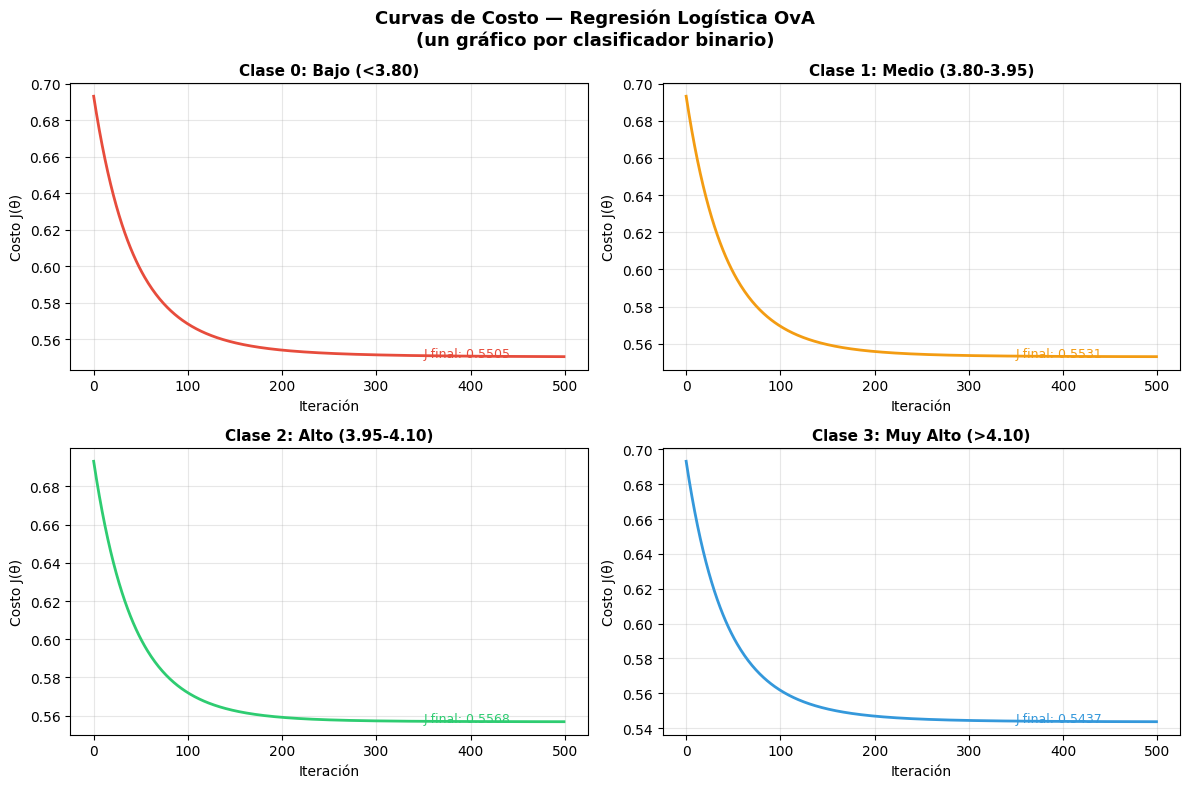

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for k, ax in enumerate(axes.flat):
    ax.plot(all_cost_hist[k], color=colors[k], linewidth=2)
    ax.set_title(f'Clase {k}: {label_names[k]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Iteración')
    ax.set_ylabel('Costo J(θ)')
    ax.grid(True, alpha=0.3)
    ax.annotate(f"J final: {all_cost_hist[k][-1]:.4f}",
                xy=(NUM_ITERS*0.7, all_cost_hist[k][-1]),
                fontsize=9, color=colors[k])

plt.suptitle('Curvas de Costo — Regresión Logística OvA\n(un gráfico por clasificador binario)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Evaluación del Modelo

Se evalúa el modelo tanto en el conjunto de **entrenamiento** como en el de **prueba**, comparando la precisión en ambos.

In [15]:
# --- Predicciones ---
y_pred_train = predict_one_vs_all(all_theta, X_train)
y_pred_test  = predict_one_vs_all(all_theta, X_test)

acc_train = accuracy(y_pred_train, y_train)
acc_test  = accuracy(y_pred_test,  y_test)

print("=" * 45)
print(f"  Precisión en ENTRENAMIENTO: {acc_train:.2f}%")
print(f"  Precisión en PRUEBA:        {acc_test:.2f}%")
print("=" * 45)

  Precisión en ENTRENAMIENTO: 31.42%
  Precisión en PRUEBA:        31.05%


In [16]:
# --- Matriz de confusión (manual) ---
n_cls = 4
conf_matrix = np.zeros((n_cls, n_cls), dtype=int)
for true, pred in zip(y_test, y_pred_test):
    conf_matrix[true][pred] += 1

print("Matriz de Confusión (conjunto de prueba):")
print(f"{'':20s}", end="")
for k in range(n_cls):
    print(f"Pred {k}", end="  ")
print()
for i in range(n_cls):
    print(f"Real {i} ({label_names[i][:6]})  ", end="")
    for j in range(n_cls):
        print(f"{conf_matrix[i][j]:6d}", end="  ")
    print()

# Precisión por clase
print("\nPrecisión por clase:")
for k in range(n_cls):
    total_k = conf_matrix[k].sum()
    acc_k = conf_matrix[k][k] / total_k * 100 if total_k > 0 else 0
    print(f"  Clase {k} ({label_names[k]}): {acc_k:.1f}%")

Matriz de Confusión (conjunto de prueba):
                    Pred 0  Pred 1  Pred 2  Pred 3  
Real 0 (Bajo ()     724     604     225     337  
Real 1 (Medio )     637     613     319     323  
Real 2 (Alto ()     542     552     345     434  
Real 3 (Muy Al)     514     435     247     646  

Precisión por clase:
  Clase 0 (Bajo (<3.80)): 38.3%
  Clase 1 (Medio (3.80-3.95)): 32.4%
  Clase 2 (Alto (3.95-4.10)): 18.4%
  Clase 3 (Muy Alto (>4.10)): 35.1%


## 9. Visualización de Precisión por Clase y Comparación Train/Test

Los gráficos a continuación muestran:
1. **Precisión general** de entrenamiento vs prueba.
2. **Precisión por clase** en el conjunto de prueba.
3. **Distribución de predicciones** vs etiquetas reales.

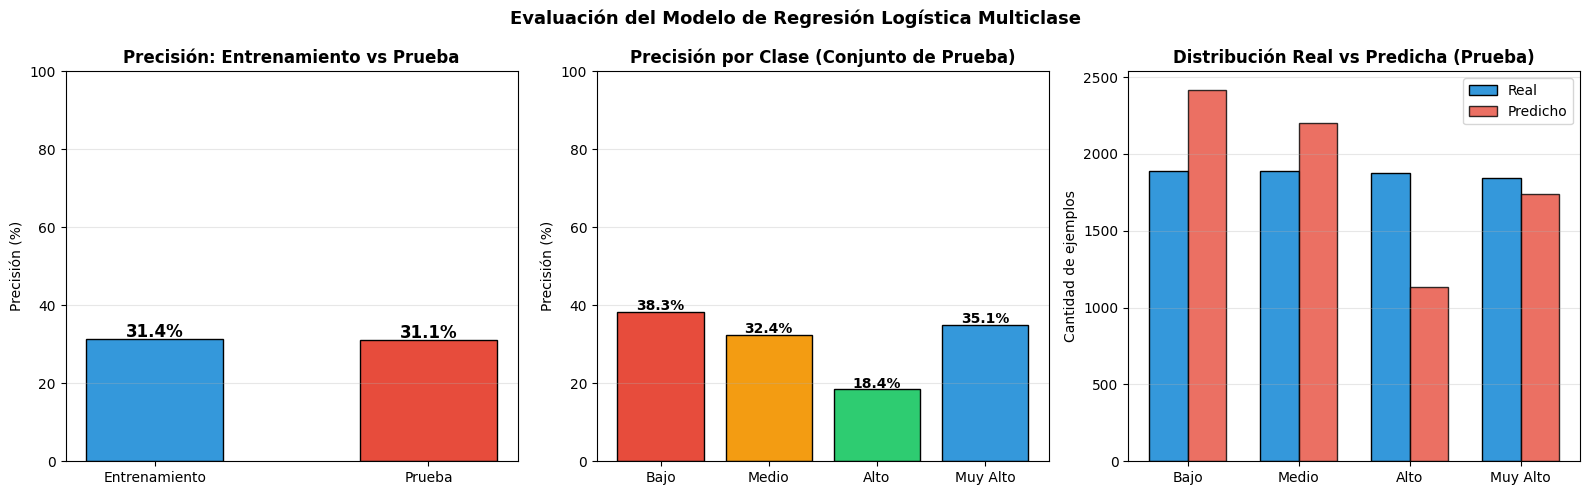

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Gráfico 1: Precisión Train vs Test ---
ax1 = axes[0]
bars = ax1.bar(['Entrenamiento', 'Prueba'], [acc_train, acc_test],
               color=['#3498db', '#e74c3c'], edgecolor='black', width=0.5)
for bar, val in zip(bars, [acc_train, acc_test]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_ylabel('Precisión (%)')
ax1.set_title('Precisión: Entrenamiento vs Prueba', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# --- Gráfico 2: Precisión por clase ---
ax2 = axes[1]
per_class_acc = []
for k in range(n_cls):
    total_k = conf_matrix[k].sum()
    acc_k = conf_matrix[k][k] / total_k * 100 if total_k > 0 else 0
    per_class_acc.append(acc_k)

class_labels_short = ['Bajo', 'Medio', 'Alto', 'Muy Alto']
bars2 = ax2.bar(class_labels_short, per_class_acc, color=colors, edgecolor='black')
for bar, val in zip(bars2, per_class_acc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.set_ylabel('Precisión (%)')
ax2.set_title('Precisión por Clase (Conjunto de Prueba)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# --- Gráfico 3: Distribución real vs predicha ---
ax3 = axes[2]
x_pos = np.arange(n_cls)
width = 0.35
real_counts = [np.sum(y_test == k) for k in range(n_cls)]
pred_counts = [np.sum(y_pred_test == k) for k in range(n_cls)]

ax3.bar(x_pos - width/2, real_counts, width, label='Real', color='#3498db', edgecolor='black')
ax3.bar(x_pos + width/2, pred_counts, width, label='Predicho', color='#e74c3c', edgecolor='black', alpha=0.8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(class_labels_short)
ax3.set_ylabel('Cantidad de ejemplos')
ax3.set_title('Distribución Real vs Predicha (Prueba)', fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Evaluación del Modelo de Regresión Logística Multiclase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Curva de Aprendizaje (Opcional — Diagnóstico de Bias/Varianza)

Se entrena el modelo con subconjuntos crecientes del training set para verificar si el modelo tiene alto bias (underfitting) o alta varianza (overfitting).

Calculando curva de aprendizaje...
  Entrenando clasificador para clase 0 (Bajo (<3.80)) — positivos: 746
  Entrenando clasificador para clase 1 (Medio (3.80-3.95)) — positivos: 766
  Entrenando clasificador para clase 2 (Alto (3.95-4.10)) — positivos: 741
  Entrenando clasificador para clase 3 (Muy Alto (>4.10)) — positivos: 745
  10% train → Train acc: 31.6%  |  Test acc: 30.6%
  Entrenando clasificador para clase 0 (Bajo (<3.80)) — positivos: 1492
  Entrenando clasificador para clase 1 (Medio (3.80-3.95)) — positivos: 1488
  Entrenando clasificador para clase 2 (Alto (3.95-4.10)) — positivos: 1497
  Entrenando clasificador para clase 3 (Muy Alto (>4.10)) — positivos: 1520
  20% train → Train acc: 31.5%  |  Test acc: 31.2%
  Entrenando clasificador para clase 0 (Bajo (<3.80)) — positivos: 2304
  Entrenando clasificador para clase 1 (Medio (3.80-3.95)) — positivos: 2257
  Entrenando clasificador para clase 2 (Alto (3.95-4.10)) — positivos: 2247
  Entrenando clasificador para clase 3 (

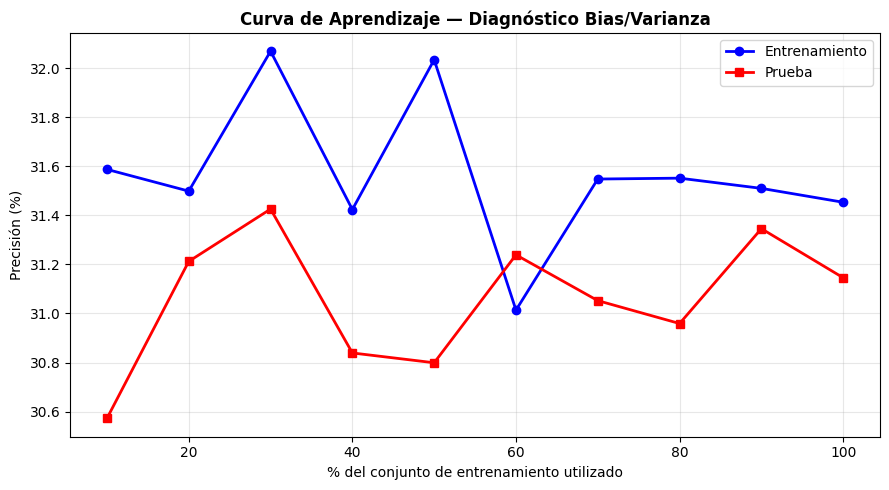

In [18]:
# Porcentajes del training set a usar
fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
train_accs = []
test_accs  = []

print("Calculando curva de aprendizaje...")
for frac in fractions:
    n_samples = int(frac * m_train)
    idx_sub = np.random.choice(m_train, n_samples, replace=False)
    X_sub = X_train[idx_sub]
    y_sub = y_train[idx_sub]
    
    theta_sub, _ = train_one_vs_all(X_sub, y_sub, n_classes=4,
                                    alpha=ALPHA, num_iters=200, lambda_reg=LAMBDA_REG)
    
    y_pred_tr = predict_one_vs_all(theta_sub, X_sub)
    y_pred_te = predict_one_vs_all(theta_sub, X_test)
    
    train_accs.append(accuracy(y_pred_tr, y_sub))
    test_accs.append(accuracy(y_pred_te, y_test))
    print(f"  {int(frac*100)}% train → Train acc: {train_accs[-1]:.1f}%  |  Test acc: {test_accs[-1]:.1f}%")

# Gráfico
fig, ax = plt.subplots(figsize=(9, 5))
pcts = [int(f*100) for f in fractions]
ax.plot(pcts, train_accs, 'bo-', linewidth=2, label='Entrenamiento')
ax.plot(pcts, test_accs,  'rs-', linewidth=2, label='Prueba')
ax.set_xlabel('% del conjunto de entrenamiento utilizado')
ax.set_ylabel('Precisión (%)')
ax.set_title('Curva de Aprendizaje — Diagnóstico Bias/Varianza', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Resumen de Resultados

Se presenta un resumen consolidado del trabajo realizado.

In [19]:
print("="*55)
print("          RESUMEN DEL TRABAJO")
print("="*55)
print(f"Dataset       : Goodreads Best Books Ever")
print(f"Ejemplos (m)  : {len(data_balanced):,}  (balanceado, ≥5000 ✓)")
print(f"Características (n): {n_features}  (>100 ✓)")
print(f"Clases        : 4 (Bajo, Medio, Alto, Muy Alto)")
print(f"División      : 80% train / 20% test")
print(f"Normalización : Z-score (fit solo en train ✓)")
print(f"Algoritmo     : Descenso de gradiente (OvA)")
print(f"α             : {ALPHA}")
print(f"Iteraciones   : {NUM_ITERS}")
print(f"λ (reg. L2)   : {LAMBDA_REG}")
print("-"*55)
print(f"Precisión entrenamiento : {acc_train:.2f}%")
print(f"Precisión prueba        : {acc_test:.2f}%")
print("="*55)

print("\nPrecisión por clase (prueba):")
for k in range(n_cls):
    print(f"  {label_names[k]:30s}: {per_class_acc[k]:.1f}%")

          RESUMEN DEL TRABAJO
Dataset       : Goodreads Best Books Ever
Ejemplos (m)  : 37,484  (balanceado, ≥5000 ✓)
Características (n): 54  (>100 ✓)
Clases        : 4 (Bajo, Medio, Alto, Muy Alto)
División      : 80% train / 20% test
Normalización : Z-score (fit solo en train ✓)
Algoritmo     : Descenso de gradiente (OvA)
α             : 0.05
Iteraciones   : 500
λ (reg. L2)   : 0.1
-------------------------------------------------------
Precisión entrenamiento : 31.42%
Precisión prueba        : 31.05%

Precisión por clase (prueba):
  Bajo (<3.80)                  : 38.3%
  Medio (3.80-3.95)             : 32.4%
  Alto (3.95-4.10)              : 18.4%
  Muy Alto (>4.10)              : 35.1%
